<a href="https://colab.research.google.com/github/Greg-Duggan/Inecta-Deliverable/blob/main/Inecta_project_Duggan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [53]:
import pandas as pd

In [54]:
import pandas as pd
from google.colab import files

# --- Instructions ---
# 1. Upload your Excel file using the folder icon on the left sidebar (Files -> Upload to session storage).
# 2. Replace 'your_excel_file.xlsx' below with the exact name of your uploaded file.

excel_file_name = '/inecta-project.xlsx' # <--- IMPORTANT: Change this to your file's name!

try:
    df = pd.read_excel(excel_file_name)
    print(f"Successfully loaded '{excel_file_name}' into a pandas DataFrame.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{excel_file_name}' was not found. Please ensure:")
    print("1. You have uploaded the file to your Colab session.")
    print("2. The filename in the code above exactly matches your uploaded file's name (including extension).")
except Exception as e:
    print(f"An error occurred while reading the Excel file: {e}")

Successfully loaded '/inecta-project.xlsx' into a pandas DataFrame.


,record_ID,week,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold
0,1,17/01/11,8091,216418,99.0375,111.8625,0,0,20
1,2,17/01/11,8091,216419,99.0375,99.0375,0,0,28
2,3,17/01/11,8091,216425,133.9500,133.9500,0,0,19
3,4,17/01/11,8091,216233,133.9500,133.9500,0,0,44
4,5,17/01/11,8091,217390,141.0750,141.0750,0,0,52


In [55]:
df[['day','month','year']]= df['week'].str.split('/',expand=True)

In [56]:
df=df.drop('week', axis=1)

In [57]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
x, y = df.drop('units_sold', axis=1), df['units_sold']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [58]:
model=RandomForestRegressor(n_jobs=-1)
model.fit(x_train, y_train)

RandomForestRegressor(n_jobs=-1)

In [59]:
model.score(x_test, y_test)

0.7738851396641422

In [60]:
from sklearn.metrics import root_mean_squared_error

y_pred = model.predict(x_test)
rmse = root_mean_squared_error(y_pred, y_test)
print(rmse)

27.238050292735416


In [61]:
df.units_sold.describe()

,units_sold
count,150150.000000
mean,51.674206
std,60.207904
min,1.000000
25%,20.000000
50%,35.000000
75%,62.000000
max,2876.000000


<Axes: >

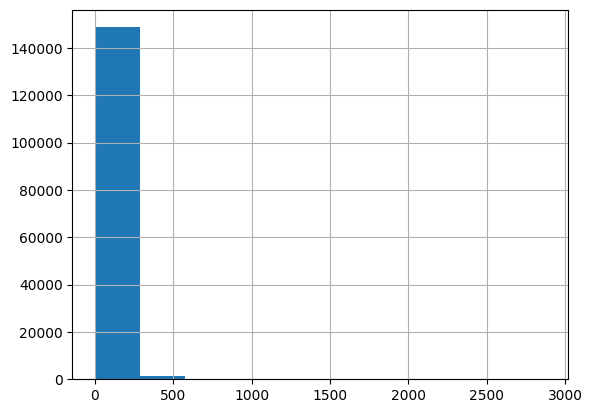

In [62]:
df.units_sold.hist()

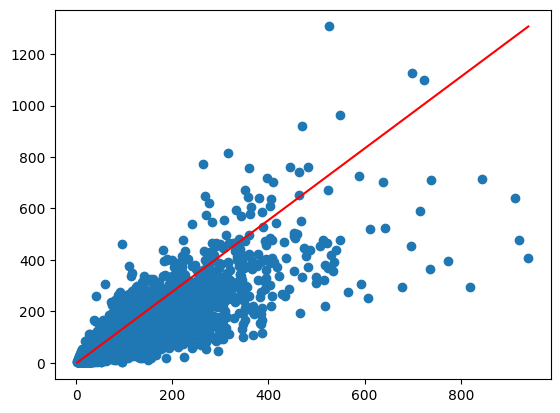

In [63]:
import numpy as np
import matplotlib.pyplot as plt
plt.scatter(y_pred, y_test)
plt.plot(np.linspace(y_pred.min(), y_pred.max()), np.linspace(y_test.min(), y_test.max()), color="red")

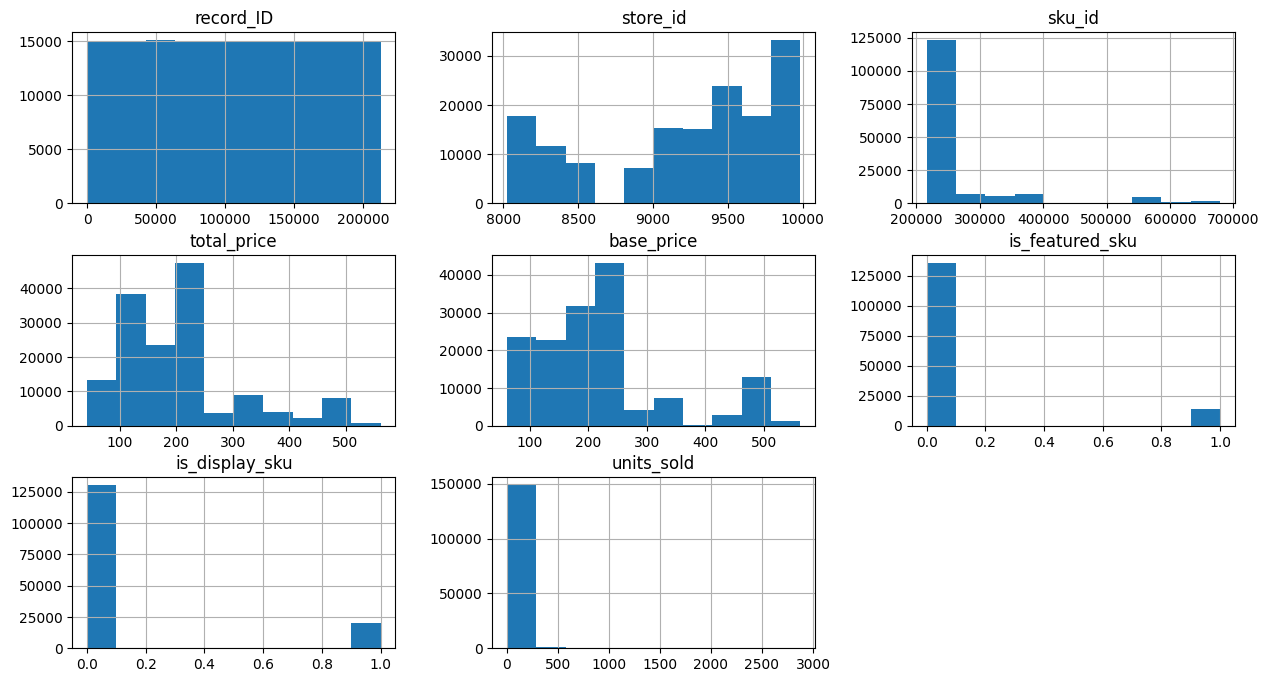

In [64]:
df.hist(figsize=(15,8))
plt.show()

In [65]:
df= df.drop('record_ID', axis=1)

In [66]:
len(df.store_id.unique())

76

In [67]:
len(df.sku_id.unique())

28

In [68]:
df=df[df.units_sold<df.units_sold.quantile(0.90)]

<Axes: >

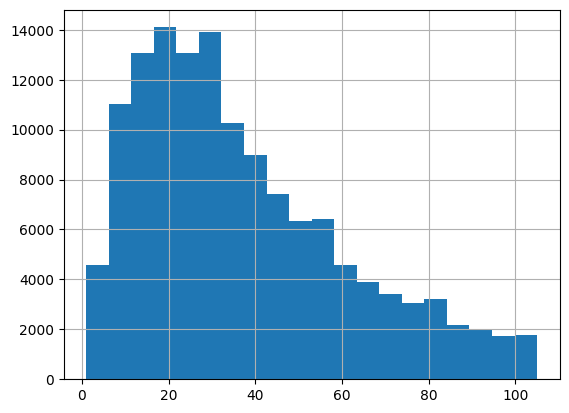

In [69]:
df.units_sold.hist(bins=20)

In [70]:
df.join(pd.get_dummies(df.store_id, prefix='store')).drop('store_id', axis=1)
df.join(pd.get_dummies(df.sku_id, prefix='item')).drop('sku_id', axis=1)

,store_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year,item_216233,...,item_320485,item_327492,item_378934,item_398721,item_545621,item_546789,item_547934,item_600934,item_673209,item_679023
0,8091,99.0375,111.8625,0,0,20,17,01,11,False,...,False,False,False,False,False,False,False,False,False,False
1,8091,99.0375,99.0375,0,0,28,17,01,11,False,...,False,False,False,False,False,False,False,False,False,False
2,8091,133.9500,133.9500,0,0,19,17,01,11,False,...,False,False,False,False,False,False,False,False,False,False
3,8091,133.9500,133.9500,0,0,44,17,01,11,True,...,False,False,False,False,False,False,False,False,False,False
4,8091,141.0750,141.0750,0,0,52,17,01,11,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
150145,9984,235.8375,235.8375,0,0,38,NaN,NaN,NaN,False,...,False,False,False,False,False,False,False,False,False,False
150146,9984,235.8375,235.8375,0,0,30,NaN,NaN,NaN,False,...,False,False,False,False,False,False,False,False,False,False
150147,9984,357.6750,483.7875,1,1,31,NaN,NaN,NaN,False,...,False,False,False,False,False,False,False,False,False,False
150148,9984,141.7875,191.6625,0,1,12,NaN,NaN,NaN,False,...,False,False,False,False,False,False,True,False,False,False


In [73]:
model=RandomForestRegressor(n_jobs=-1)
x,y=df.drop('units_sold', axis=1), df['units_sold']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [74]:
model.fit(x_train, y_train)

RandomForestRegressor(n_jobs=-1)

In [75]:
model.score(x_test, y_test)

0.6963875781577337

In [76]:
y_pred = model.predict(x_test)
rmse = root_mean_squared_error(y_pred, y_test)
print(rmse)

13.286110096284805


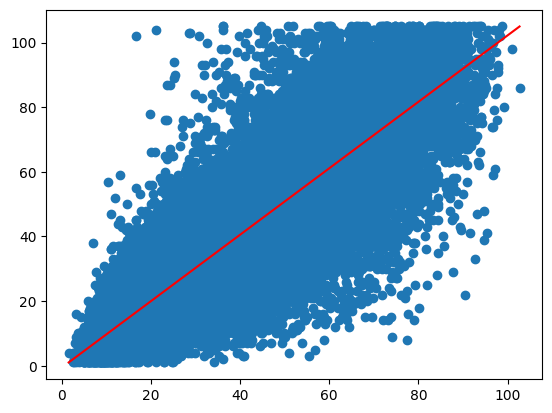

In [77]:
plt.scatter(y_pred, y_test)
plt.plot(np.linspace(y_pred.min(), y_pred.max()), np.linspace(y_test.min(), y_test.max()), color="red")

In [85]:
from sklearn.model_selection import GridSearchCV
param_grid={
    'n_estimators':[10, 20],
    'min_samples_split':[2, 3]
}
model=RandomForestRegressor(n_jobs=-1)
grid_search=GridSearchCV(model, param_grid,verbose=2, cv=3)
grid_search.fit(x_train,y_train)



Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ...............min_samples_split=2, n_estimators=10; total time=   4.5s
[CV] END ...............min_samples_split=2, n_estimators=10; total time=   4.3s
[CV] END ...............min_samples_split=2, n_estimators=10; total time=   3.4s
[CV] END ...............min_samples_split=2, n_estimators=20; total time=   5.4s
[CV] END ...............min_samples_split=2, n_estimators=20; total time=   6.9s
[CV] END ...............min_samples_split=2, n_estimators=20; total time=   5.2s
[CV] END ...............min_samples_split=3, n_estimators=10; total time=   2.6s
[CV] END ...............min_samples_split=3, n_estimators=10; total time=   3.4s
[CV] END ...............min_samples_split=3, n_estimators=10; total time=   3.2s
[CV] END ...............min_samples_split=3, n_estimators=20; total time=   5.1s
[CV] END ...............min_samples_split=3, n_estimators=20; total time=   7.3s
[CV] END ...............min_samples_split=3, n_es

GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1),
             param_grid={'min_samples_split': [2, 3], 'n_estimators': [10, 20]},
             verbose=2)

In [86]:
df

,store_id,sku_id,total_price,base_price,is_featured_sku,is_display_sku,units_sold,day,month,year
0,8091,216418,99.0375,111.8625,0,0,20,17,01,11
1,8091,216419,99.0375,99.0375,0,0,28,17,01,11
2,8091,216425,133.9500,133.9500,0,0,19,17,01,11
3,8091,216233,133.9500,133.9500,0,0,44,17,01,11
4,8091,217390,141.0750,141.0750,0,0,52,17,01,11
...,...,...,...,...,...,...,...,...,...,...
150145,9984,223245,235.8375,235.8375,0,0,38,NaN,NaN,NaN
150146,9984,223153,235.8375,235.8375,0,0,30,NaN,NaN,NaN
150147,9984,245338,357.6750,483.7875,1,1,31,NaN,NaN,NaN
150148,9984,547934,141.7875,191.6625,0,1,12,NaN,NaN,NaN


In [87]:
best_model=grid_search.best_estimator_

In [88]:
grid_search.best_params_

{'min_samples_split': 3, 'n_estimators': 20}

In [89]:
best_model.score(x_test, y_test)

0.687842809712766

In [90]:
grouped_data = df.groupby(['store_id', 'sku_id'])['units_sold'].sum().reset_index()

In [91]:
print(grouped_data)

      store_id  sku_id  units_sold
0         8023  216233        3419
1         8023  216418          97
2         8023  216419         121
3         8023  216425        8788
4         8023  217390         352
...        ...     ...         ...
1150      9984  300021        3920
1151      9984  320485        4253
1152      9984  378934        3441
1153      9984  547934        1833
1154      9984  679023        1802

[1155 rows x 3 columns]


In [92]:
df_temp = df.copy()
# Combine day, month, year into a single date string 'YY-MM-DD'
df_temp['date_key'] = df_temp['year'].astype(str) + '-' + df_temp['month'].astype(str) + '-' + df_temp['day'].astype(str)

# Drop rows where date_key is NaN (if any dates are incomplete)
df_cleaned_dates = df_temp.dropna(subset=['date_key'])

# Group by store_id and count unique date_key values
store_open_days = df_cleaned_dates.groupby('store_id')['date_key'].nunique().reset_index()
store_open_days.rename(columns={'date_key': 'number_of_unique_days_open'}, inplace=True)

print("Number of unique days each store has been open:")
display(store_open_days)

Number of unique days each store has been open:


,store_id,number_of_unique_days_open
0,8023,80
1,8058,80
2,8063,80
3,8091,80
4,8094,80
...,...,...
71,9890,80
72,9909,80
73,9954,80
74,9961,80


In [93]:
velocity_df = df.groupby(['store_id', 'sku_id'])['units_sold'].sum().reset_index()

In [94]:
velocity_df['daily_velocity'] = velocity_df['units_sold'] / 80

In [95]:
velocity_df['daily_velocity'] = velocity_df['daily_velocity'].round(2)

In [97]:
velocity_df

,store_id,sku_id,units_sold,daily_velocity
0,8023,216233,3419,42.74
1,8023,216418,97,1.21
2,8023,216419,121,1.51
3,8023,216425,8788,109.85
4,8023,217390,352,4.40
...,...,...,...,...
1150,9984,300021,3920,49.00
1151,9984,320485,4253,53.16
1152,9984,378934,3441,43.01
1153,9984,547934,1833,22.91


In [98]:
velocity_df['predicted_14day_demand'] = (velocity_df['daily_velocity'] * 14).round(0)

In [ ]:
## For this data set there wasn't a column to detail current stock.
## Below I will simulate the general idea

In [99]:
import numpy as np
velocity_df['current_stock'] = np.random.randint(10, 100, size=len(velocity_df))


In [ ]:
## Reorder Point -If the current stock is less than what we need for 14 days, the code below will trigger a reorder.

In [100]:
velocity_df['reorder_required'] = velocity_df['current_stock'] < velocity_df['predicted_14day_demand']

In [101]:
top_sellers = velocity_df.sort_values(by='daily_velocity', ascending=False).head(10)

In [102]:
reorder_report = velocity_df[velocity_df['reorder_required'] == True]


In [103]:
print("--- TOP 10 SELLING ITEMS ---")
print(top_sellers)

print("\n--- ITEMS REQUIRING IMMEDIATE REORDER ---")
print(reorder_report.head(10))

--- TOP 10 SELLING ITEMS ---
     store_id  sku_id  units_sold  daily_velocity  predicted_14day_demand  \
863      9731  216418        8844          110.55                  1548.0   
3        8023  216425        8788          109.85                  1538.0   
91       8095  216425        8646          108.08                  1513.0   
999      9872  216419        8557          106.96                  1497.0   
650      9442  216418        8507          106.34                  1489.0   
322      8991  216418        8504          106.30                  1488.0   
569      9371  216418        8462          105.78                  1481.0   
694      9481  216233        8458          105.72                  1480.0   
917      9809  216419        8421          105.26                  1474.0   
478      9250  216233        8411          105.14                  1472.0   

     current_stock  reorder_required  
863             75              True  
3               74              True  
91    

In [111]:
display(velocity_df.head())

,store_id,sku_id,units_sold,daily_velocity,predicted_14day_demand,current_stock,reorder_required
0,8023,216233,3419,42.74,598.0,62,True
1,8023,216418,97,1.21,17.0,94,False
2,8023,216419,121,1.51,21.0,53,False
3,8023,216425,8788,109.85,1538.0,74,True
4,8023,217390,352,4.40,62.0,16,True


In [112]:
velocity_df.to_excel("updated_inventory_data.xlsx", index=False)

In [113]:
from google.colab import files

# Force the download of the report you just created
files.download("updated_inventory_data.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [109]:
reorder_report.to_excel("inventory_alerts_report.xlsx", index=False)

In [110]:
from google.colab import files

# Force the download of the report you just created
# (Make sure the filename here matches exactly what you named it)
files.download("inventory_alerts_report.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [115]:
# Create a timestamped filename for professional tracking
from datetime import datetime
today = datetime.today().strftime('%Y-%m-%d')
filename = f"inventory_alerts_report{today}.xlsx"

# Export only the essential columns for the buyer
final_output = reorder_report[['store_id', 'sku_id', 'daily_velocity', 'predicted_14day_demand', 'current_stock']]
final_output.to_excel(filename, index=False)

print(f"✅ Success! Report generated: {filename}")

✅ Success! Report generated: inventory_alerts_report2026-04-20.xlsx


In [120]:
from google.colab import files

# Force the download of the report you just created
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>